In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from helperfunctions import intern_constants as ic
from helperfunctions import helper as hfn
import pandas as pd

In [2]:
def plot_blade_pitch(df, b1, b2, b3, figsize=(15,4)):
    pairs= [(b1,b2), (b1,b3), (b2,b3)]
    
    wt_id = 0
    arrays=[]
    for x,y in pairs:
        X,Y = df[x].to_numpy(float), df[y].to_numpy(float)
        wt_id = df["WT_ID"].iat[0]
        arrays.append((X,Y))
        
    
    
    gmin = min(np.nanmin(A) for A,B in arrays for A in (A,B))
    gmax = max(np.nanmax(A) for A,B in arrays for A in (A,B))
    
    fig, axes= plt.subplots(1,3, figsize=figsize)
    for ax, (x,y), (X,Y) in zip(axes, pairs, arrays):
        ax.scatter(X,Y, s=6, alpha=0.4)
        ax.plot([gmin, gmax], [gmin, gmax], linewidth=1) #y=x
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(gmin, gmax)
        ax.set_ylim(gmin, gmax)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"WT={wt_id}:\n {x} vs \n{y}")
    
    fig.tight_layout()
    return fig, axes

In [3]:
fo = hfn.load_feature_order()
print(*fo, sep="\n")
b1 = "Blade angle (pitch position) A (°)"
b2 = "Blade angle (pitch position) B (°)"
b3 = "Blade angle (pitch position) C (°)"
files = glob(os.path.join(ic.PATH_IMPUTED, "*.csv"))


Ambient temperature (converter) (°C)
Drive train acceleration (mm/ss)
Gear oil inlet pressure (bar)
Gear oil pump pressure (bar)
Gearbox speed (RPM)
Generator bearing front temperature (°C)
Generator bearing rear temperature (°C)
Generator RPM (RPM)
Hub temperature (°C)
Motor current axis 1 (A)
Motor current axis 2 (A)
Motor current axis 3 (A)
Nacelle ambient temperature (°C)
Nacelle position (°)
Nacelle temperature (°C)
Power (kW)
Rotor bearing temp (°C)
Rotor speed (RPM)
Stator temperature 1 (°C)
Temp. top box (°C)
Temperature motor axis 1 (°C)
Temperature motor axis 2 (°C)
Temperature motor axis 3 (°C)
Vane position 1+2 (°)
Wind direction (°)
Wind speed (m/s)
Blade angle (pitch position) A (°)
Blade angle (pitch position) B (°)
Blade angle (pitch position) C (°)
Front bearing temperature (°C)
Gear oil inlet temperature (°C)
Gear oil temperature (°C)
Rear bearing temperature (°C)
Tower Acceleration X (mm/ss)
Tower Acceleration Y (mm/ss)
Transformer cell temperature (°C)
Transformer t

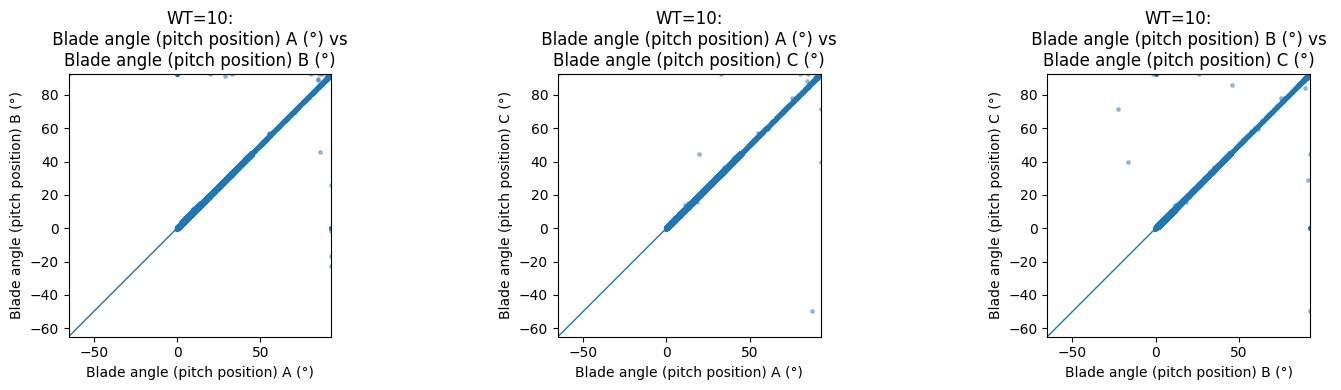

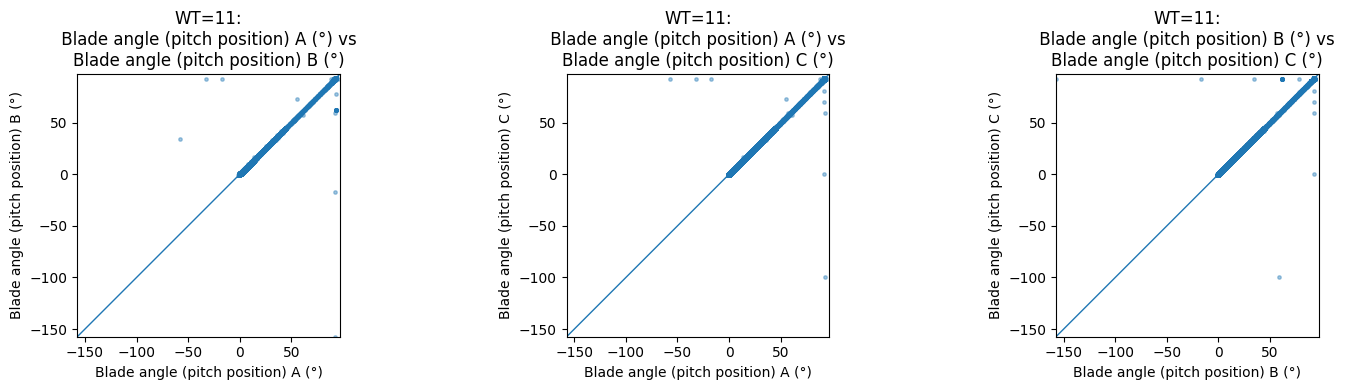

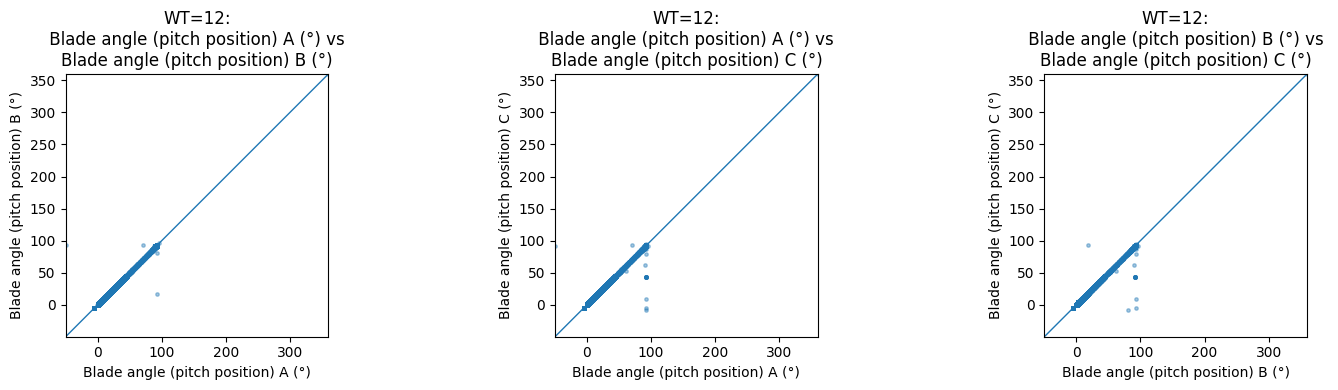

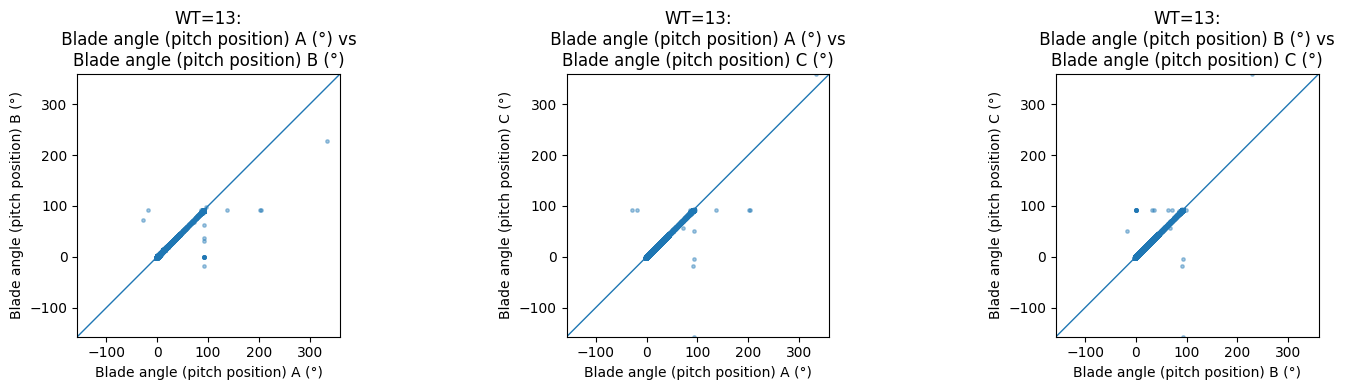

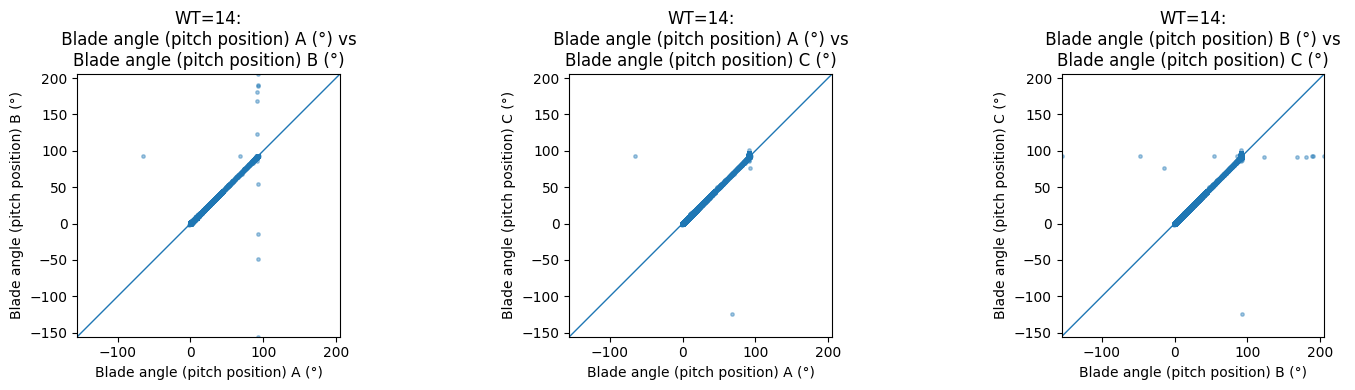

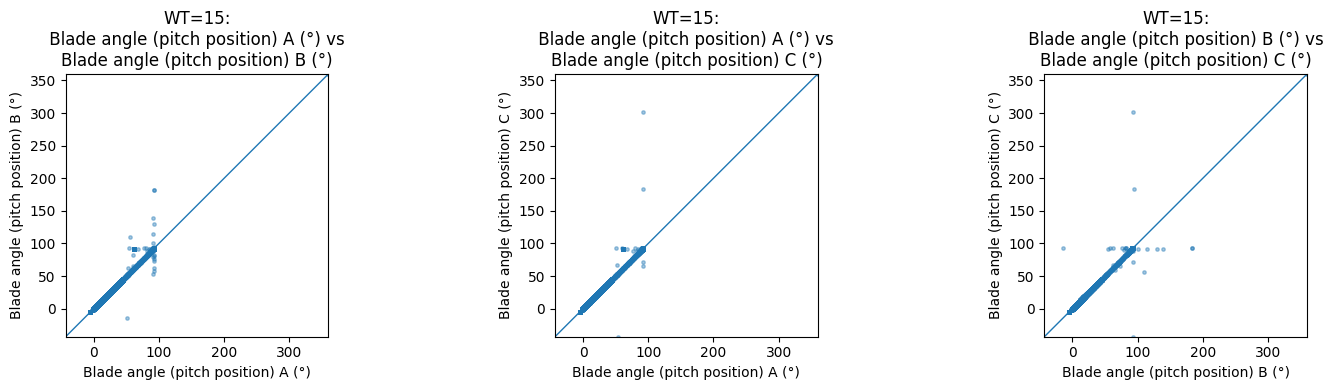

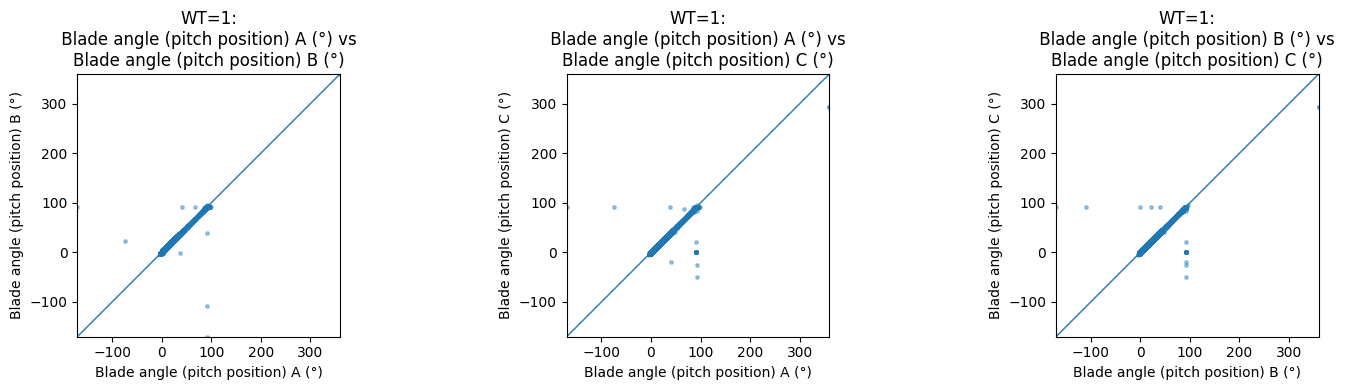

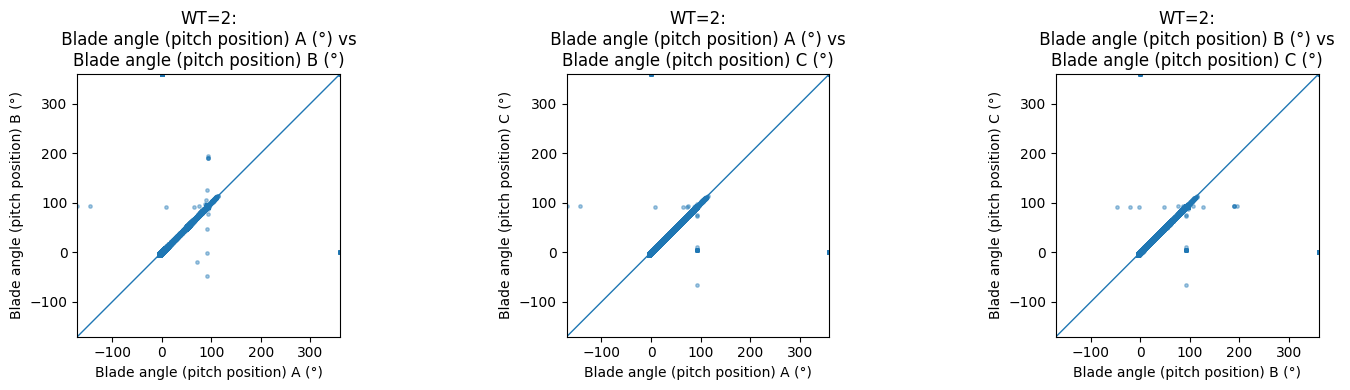

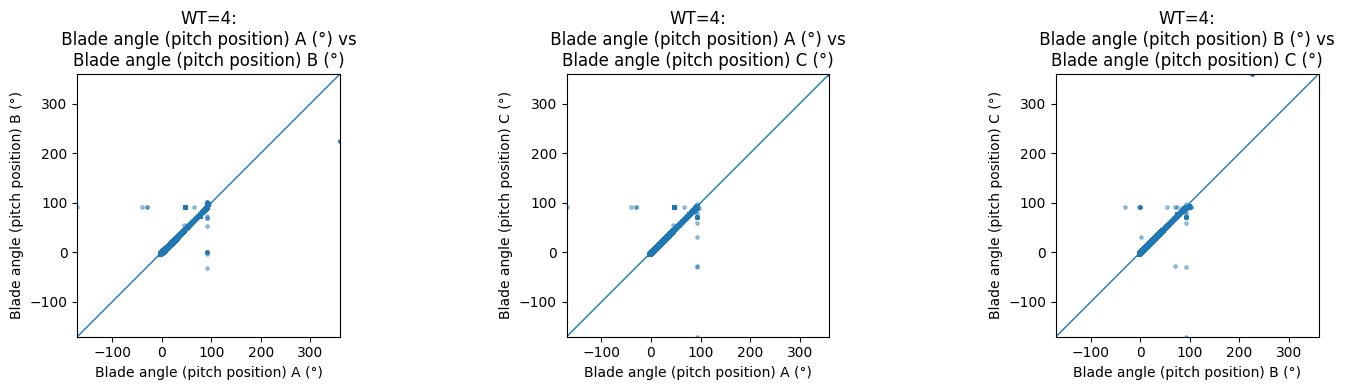

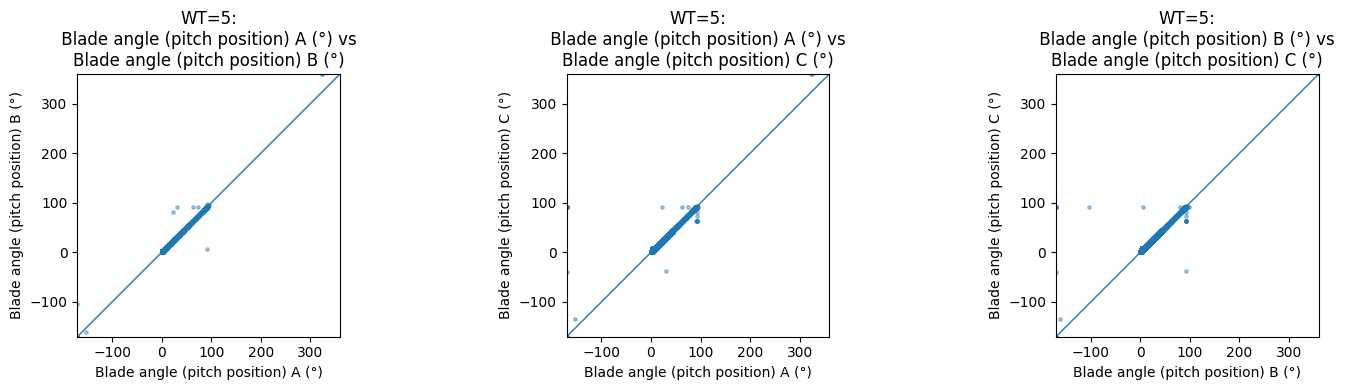

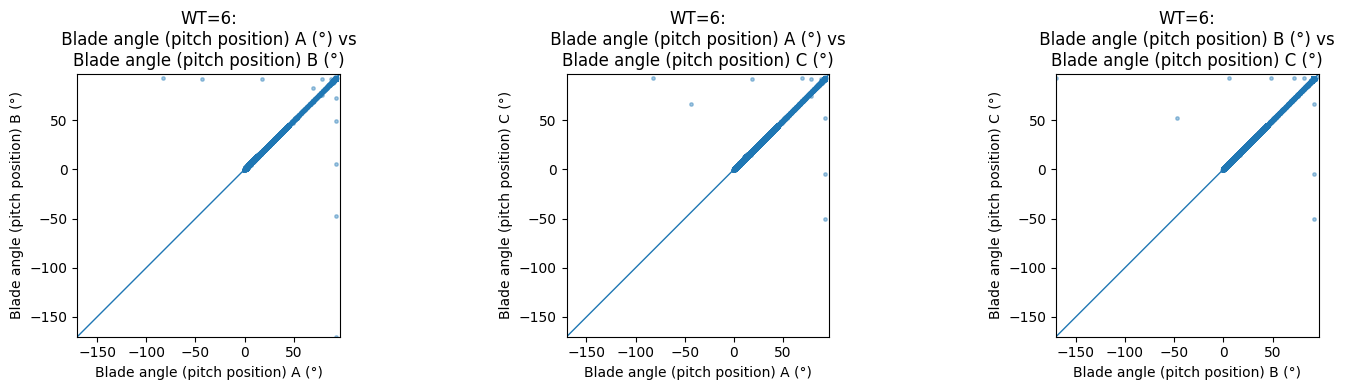

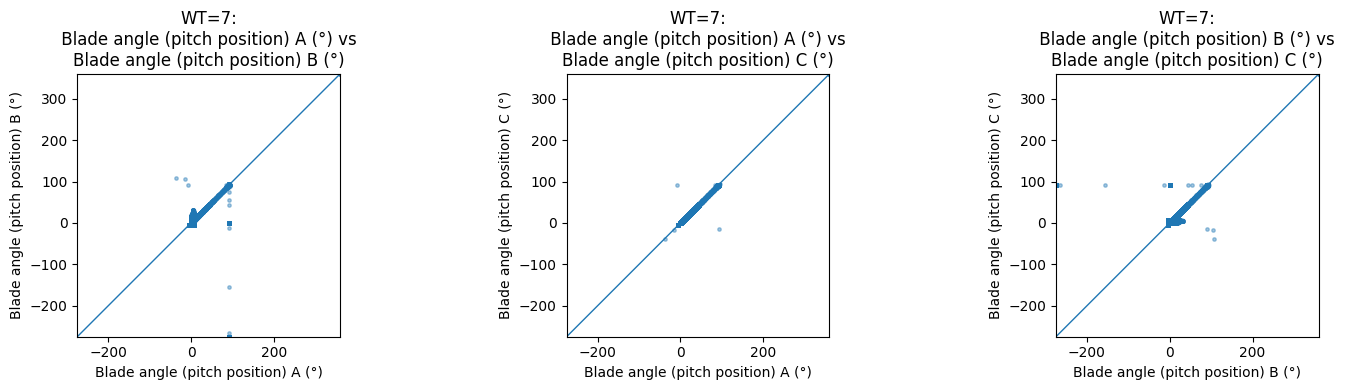

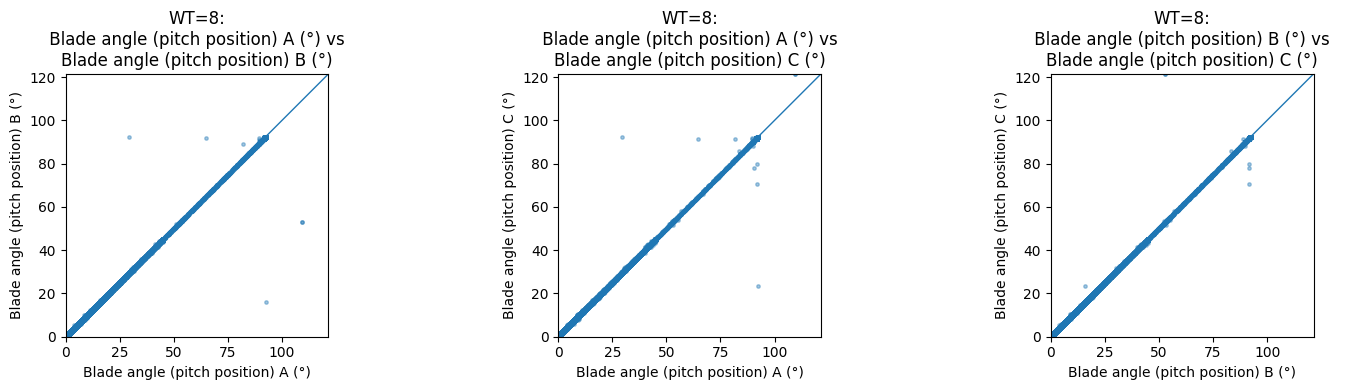

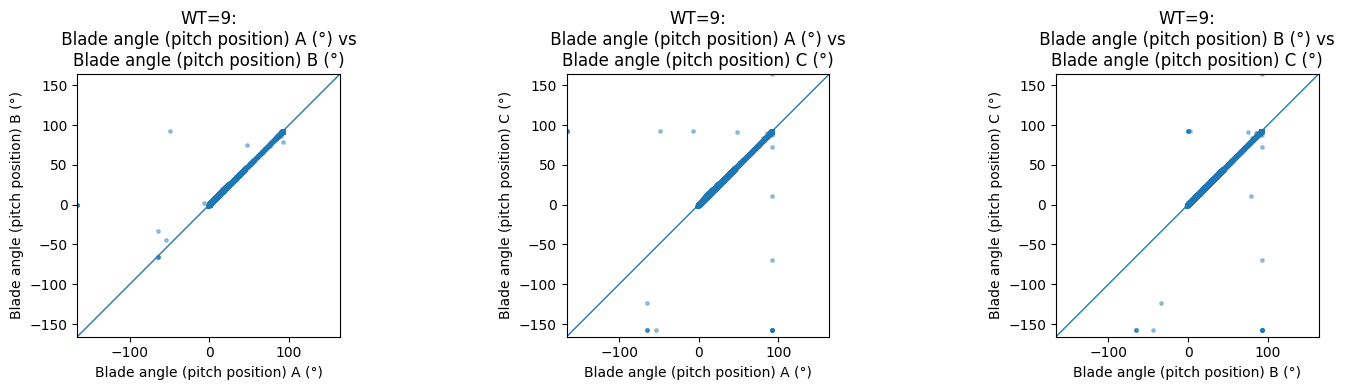

In [4]:

for f in files:
    df = pd.read_csv(f)
    plot_blade_pitch(df, b1,b2,b3)